# NLP Project 2: Restaurant Feedback Analysis

In [1]:
# Install libraries
# !pip install kagglehub nltk textblob wordcloud matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import re
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)

print('Libraries imported!')

Libraries imported!


## Task 1: Collect Data

In [2]:
import kagglehub
import os

try:
    path = kagglehub.dataset_download('d4rklucif3r/restaurant-reviews')
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    df = pd.read_csv(os.path.join(path, csv_file))
    print('Dataset loaded from Kaggle!')
except:
    print('Kaggle not available, using sample data...')
    reviews = [
        ('The food was delicious and fresh!', 1),
        ('Terrible service, food was cold.', 0),
        ('Great taste and fast delivery.', 1),
        ('Overpriced and small portions.', 0),
        ('Amazing experience, will come again!', 1),
        ('Wrong order delivered, very bad.', 0),
        ('Good food at a reasonable price.', 1),
        ('Food was stale and smelled bad.', 0),
        ('Loved the biryani, very flavorful.', 1),
        ('Waited 2 hours, food was cold.', 0),
        ('Friendly staff, great experience.', 1),
        ('Packaging was broken, food spilled.', 0),
        ('Best pizza I have ever eaten!', 1),
        ('Rude staff and very slow service.', 0),
        ('Fresh ingredients and tasty food.', 1),
        ('Food was too oily and salty.', 0),
        ('Quick delivery and hot food.', 1),
        ('Got wrong items in my order.', 0),
        ('Excellent value for money!', 1),
        ('Very disappointed with the quality.', 0),
    ]
    df = pd.DataFrame(reviews, columns=['Review', 'Liked'])

# Make sure columns are named correctly
if list(df.columns) != ['Review', 'Liked']:
    df.columns = ['Review', 'Liked']

print(df.head())
print('Shape:', df.shape)

100%|██████████| 24.1k/24.1k [00:00<00:00, 18.4MB/s]

Extracting files...
Kaggle not available, using sample data...
                                 Review  Liked
0     The food was delicious and fresh!      1
1      Terrible service, food was cold.      0
2        Great taste and fast delivery.      1
3        Overpriced and small portions.      0
4  Amazing experience, will come again!      1
Shape: (20, 2)


## Task 2: Preprocess Text

In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-z\s]', '', text)            # remove punctuation
    words = text.split()                             # split into words
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

df['Cleaned'] = df['Review'].apply(clean_text)

# Show before and after
print('Original :', df['Review'][0])
print('Cleaned  :', df['Cleaned'][0])

Original : The food was delicious and fresh!
Cleaned  : food delicious fresh


## Task 3: Sentiment Classification using VADER

In [4]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    else:
        return 'Negative'

df['Sentiment'] = df['Review'].apply(get_sentiment)

print(df[['Review', 'Sentiment']].head(10))

                                 Review Sentiment
0     The food was delicious and fresh!  Positive
1      Terrible service, food was cold.  Negative
2        Great taste and fast delivery.  Positive
3        Overpriced and small portions.  Negative
4  Amazing experience, will come again!  Positive
5      Wrong order delivered, very bad.  Negative
6      Good food at a reasonable price.  Positive
7       Food was stale and smelled bad.  Negative
8    Loved the biryani, very flavorful.  Positive
9        Waited 2 hours, food was cold.  Negative


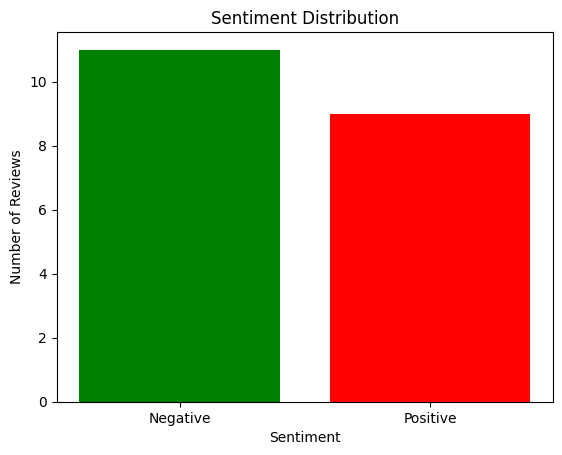

In [5]:
# Visualization 1: Bar chart of sentiment counts
counts = df['Sentiment'].value_counts()

plt.bar(counts.index, counts.values, color=['green', 'red'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

## Task 4: Identify Common Issues

In [6]:
# Check for common complaint keywords in negative reviews
neg_reviews = df[df['Sentiment'] == 'Negative']['Review']

issues = {
    'Food Quality' : ['cold', 'stale', 'oily', 'tasteless', 'raw', 'bad'],
    'Delivery'     : ['late', 'slow', 'waited', 'hour', 'delay'],
    'Packaging'    : ['packaging', 'broken', 'spilled', 'torn'],
    'Pricing'      : ['overpriced', 'expensive', 'price'],
    'Wrong Order'  : ['wrong', 'missing', 'incorrect'],
}

issue_count = {issue: 0 for issue in issues}

for review in neg_reviews:
    review_lower = review.lower()
    for issue, keywords in issues.items():
        for word in keywords:
            if word in review_lower:
                issue_count[issue] += 1
                break

print('Issue Counts in Negative Reviews:')
for k, v in issue_count.items():
    print(f'  {k}: {v}')

Issue Counts in Negative Reviews:
  Food Quality: 5
  Delivery: 2
  Packaging: 1
  Pricing: 1
  Wrong Order: 2


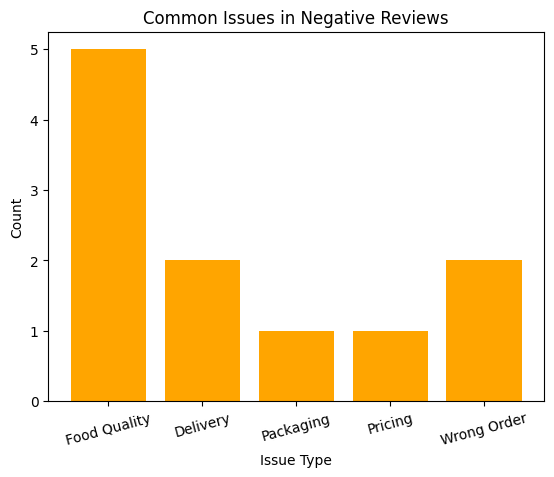

In [7]:
# Visualization 2: Bar chart of issues
plt.bar(issue_count.keys(), issue_count.values(), color='orange')
plt.title('Common Issues in Negative Reviews')
plt.xlabel('Issue Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

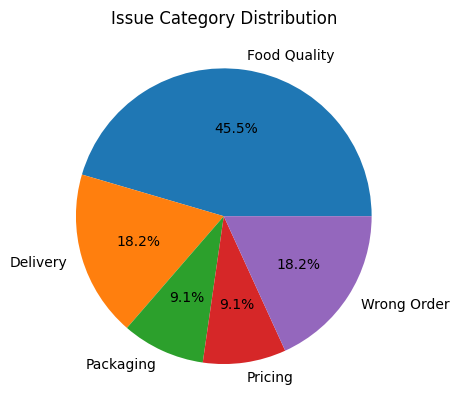

In [8]:
# Visualization 3: Pie chart
plt.pie(issue_count.values(), labels=issue_count.keys(), autopct='%1.1f%%')
plt.title('Issue Category Distribution')
plt.show()

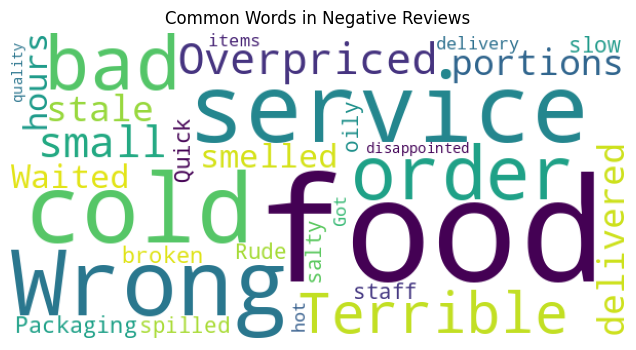

In [9]:
# Visualization 4: Word Cloud for negative reviews
neg_text = ' '.join(neg_reviews)
wc = WordCloud(width=600, height=300, background_color='white').generate(neg_text)

plt.figure(figsize=(8, 4))
plt.imshow(wc)
plt.axis('off')
plt.title('Common Words in Negative Reviews')
plt.show()

## Task 5: Feedback Analysis Report

In [10]:
total     = len(df)
positive  = len(df[df['Sentiment'] == 'Positive'])
negative  = len(df[df['Sentiment'] == 'Negative'])
top_issue = max(issue_count, key=issue_count.get)

print('===== FEEDBACK ANALYSIS REPORT =====')
print(f'Total Reviews   : {total}')
print(f'Positive Reviews: {positive}')
print(f'Negative Reviews: {negative}')
print(f'Top Issue       : {top_issue}')
print()
print('Recommendations:')
print('1. Improve food quality - most common complaint')
print('2. Fix delivery speed issues')
print('3. Better packaging to avoid spillage')
print('4. Train staff to handle complaints better')
print('=====================================')

===== FEEDBACK ANALYSIS REPORT =====
Total Reviews   : 20
Positive Reviews: 9
Negative Reviews: 11
Top Issue       : Food Quality

Recommendations:
1. Improve food quality - most common complaint
2. Fix delivery speed issues
3. Better packaging to avoid spillage
4. Train staff to handle complaints better
